# 01. Logistic Regression

This notebook trains a `Logistic Regression` baseline on the wallet-level table.

Included by default:

- stratified train/val/test split
- validation-based threshold tuning
- rich test metrics
- ROC curve, PR curve, confusion matrix, score histogram, threshold sweeps, calibration curve

Default restriction:

- `ADD_GRAPH_STATS = False`
- only wallet feature columns are used


In [1]:
from pathlib import Path
import sys

import pandas as pd

sys.path.append(str(Path.cwd()))

from tabular_model_utils import (
    build_tabular_dataset,
    classification_report_df,
    fit_and_evaluate_model,
    plot_evaluation_dashboard,
    plot_feature_importance,
    plot_mlp_learning_curve,
    set_seed,
)


In [2]:
MODEL_NAME = "logistic_regression"
FEATURE_GROUP = "features"
ADD_GRAPH_STATS = False
RANDOM_STATE = 42
THRESHOLD_OBJECTIVE = "f1"

set_seed(RANDOM_STATE)


In [3]:
dataset = build_tabular_dataset(
    feature_group=FEATURE_GROUP,
    add_graph_stats=ADD_GRAPH_STATS,
    random_state=RANDOM_STATE,
)

display(dataset["split_df"])
print("Number of input features:", len(dataset["feature_cols"]))
print("Scale positive weight:", round(dataset["scale_pos_weight"], 4))


,split,rows,positives,positive_ratio
0,train,7000,788,0.112571
1,val,1500,169,0.112667
2,test,1500,169,0.112667


Number of input features: 8
Scale positive weight: 7.8832


In [4]:
result = fit_and_evaluate_model(
    model_name=MODEL_NAME,
    dataset=dataset,
    random_state=RANDOM_STATE,
    threshold_objective=THRESHOLD_OBJECTIVE,
)

metrics_df = pd.DataFrame([result["metrics"]]).T.rename(columns={0: "value"})
display(metrics_df)


,value
Threshold,0.550000
PR-AUC,0.442206
ROC-AUC,0.836342
F1,0.507123
Precision,0.489011
Recall,0.526627
Specificity,0.930128
NPV,0.939302
Balanced-Accuracy,0.728377
MCC,0.442305


In [5]:
report_df = classification_report_df(
    dataset["y_test"].to_numpy(),
    result["test_prob"],
    result["threshold"],
)
display(report_df)


,precision,recall,f1-score,support
0,0.939302,0.930128,0.934692,1331.000000
1,0.489011,0.526627,0.507123,169.000000
accuracy,0.884667,0.884667,0.884667,0.884667
macro avg,0.714156,0.728377,0.720907,1500.000000
weighted avg,0.888569,0.884667,0.886519,1500.000000


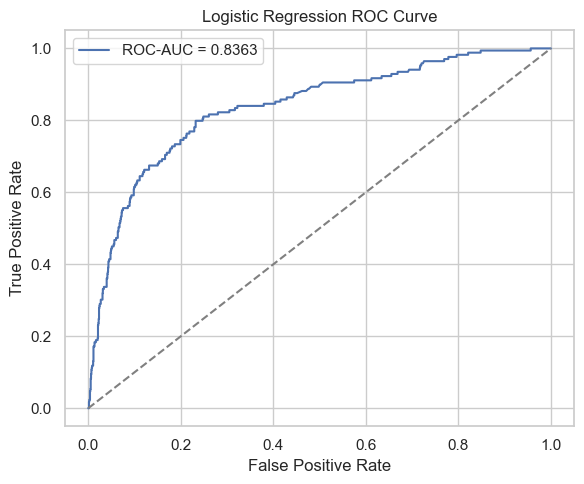

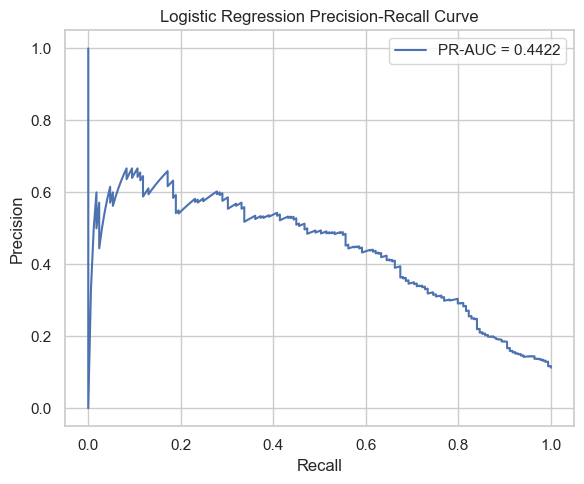

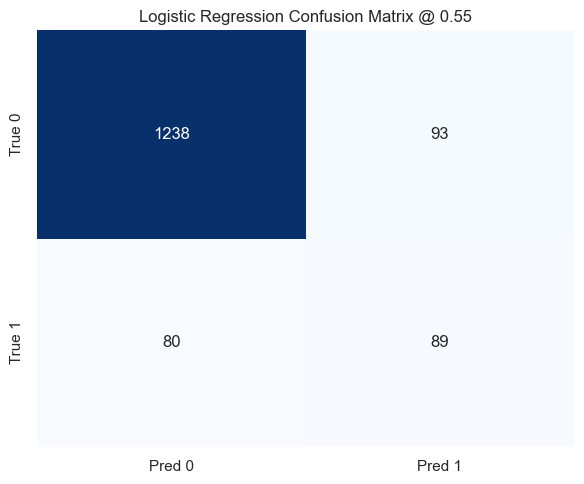

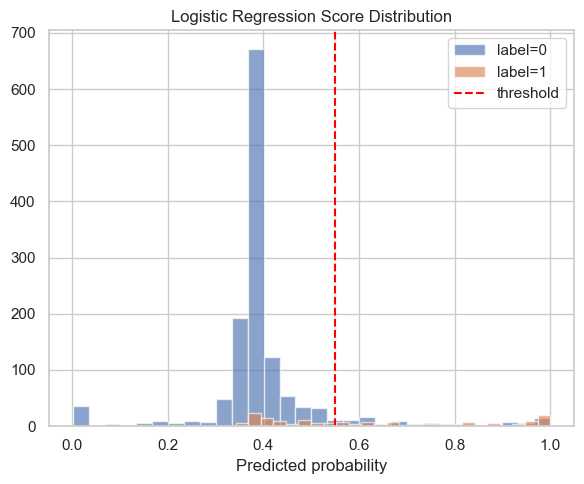

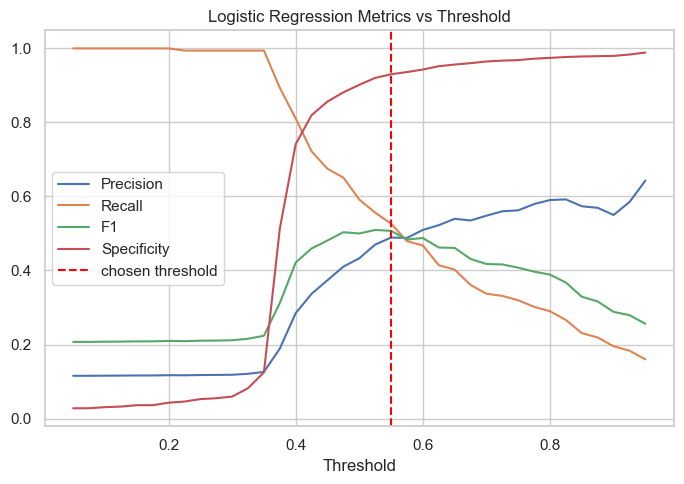

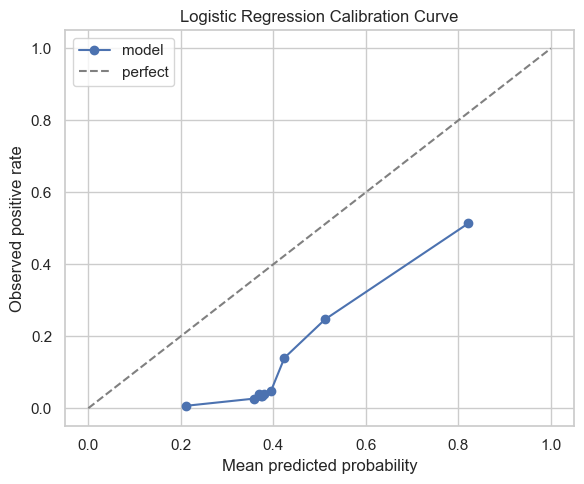

In [6]:
plot_evaluation_dashboard(
    y_true=dataset["y_test"].to_numpy(),
    y_prob=result["test_prob"],
    threshold=result["threshold"],
    title_prefix=MODEL_NAME.replace("_", " ").title(),
)


In [7]:
test_node_rows = dataset["nodes_df"].loc[dataset["test_idx"]].copy()
test_node_rows["predicted_probability"] = result["test_prob"]
test_node_rows["predicted_label"] = (result["test_prob"] >= result["threshold"]).astype(int)
suspicious_wallets = test_node_rows.sort_values("predicted_probability", ascending=False).head(25)
display(
    suspicious_wallets[
        [
            "node_id",
            "label",
            "predicted_probability",
            "predicted_label",
            "full_total_degree",
            "sub_total_degree",
        ]
    ]
)


,node_id,label,predicted_probability,predicted_label,full_total_degree,sub_total_degree
124,16510,0,1.000000,1,480,82
518,70340,0,1.000000,1,135,45
2046,258361,1,1.000000,1,2,0
2478,308537,1,1.000000,1,1,1
1834,235606,1,1.000000,1,5,5
328,44153,0,1.000000,1,235,43
1539,204115,1,1.000000,1,1,1
2315,288808,0,0.999999,1,67,2
354,47857,0,0.999983,1,693,167
2732,341302,1,0.999982,1,4,2


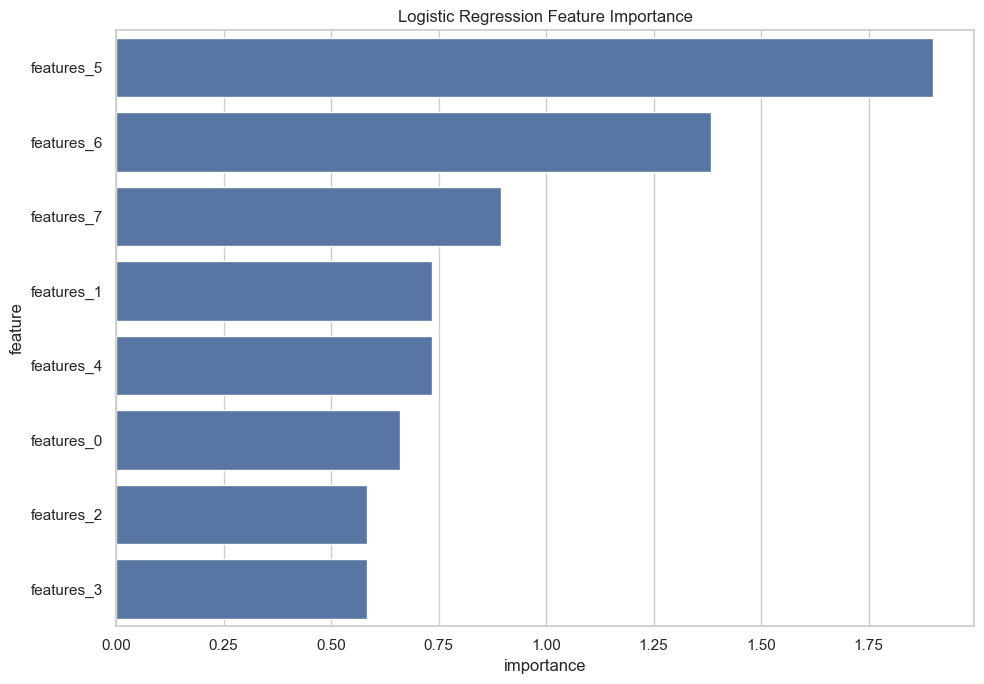

,feature,importance,signed_value
5,features_5,1.900116,-1.900116
6,features_6,1.383328,1.383328
7,features_7,0.895477,-0.895477
1,features_1,0.734826,0.734826
4,features_4,0.734826,0.734826
0,features_0,0.659383,0.659383
2,features_2,0.584186,0.584186
3,features_3,0.584186,0.584186


In [8]:
plot_feature_importance(
    model=result["model"],
    feature_cols=dataset["feature_cols"],
    title=f"{MODEL_NAME.replace('_', ' ').title()} Feature Importance",
    top_n=20,
)


## Notes

Use `PR-AUC`, `Recall`, `Precision`, `F1`, `Balanced-Accuracy`, and `MCC` together when comparing this model with the other baselines.
